##### DATA 620 - Week Four - Part 2 
## Assignment High Frequency Words
**Author**
- Barakat Adigun

## Introduction

This project analyzes the frequency distribution of words in a literary corpus from the Project Gutenberg collection available through the NLTK library. For this analysis, I selected Persuasion by Jane Austen because it is a well-known English novel with a sufficiently large vocabulary to demonstrate common patterns in natural language.
The objectives of this assignment are to determine the number of unique words in the corpus, identify the words that account for half of all word occurrences, examine the 200 most frequently used words, and visualize their relative frequencies. Finally, the analysis evaluates whether the observed word frequencies follow Zipf's Law, which states that the frequency of a word is inversely proportional to its rank in the frequency table.
To prepare the text for analysis, all words are converted to lowercase and punctuation and non-alphabetic characters are removed. In this notebook, a unique word is defined as any distinct alphabetic token after converting all text to lowercase. This ensures that words such as "The" and "the" are treated as the same word while punctuation is excluded from the analysis.

In [10]:
## Import Libraries

import nltk
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
import re

nltk.download('gutenberg')
nltk.download('punkt')

from nltk.corpus import gutenberg

[nltk_data] Downloading package gutenberg to
[nltk_data]     /Users/baadigun/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!
[nltk_data] Downloading package punkt to /Users/baadigun/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## Load the Corpus

For this assignment I selected *Pride and Prejudice* from the Project Gutenberg corpus included with NLTK.
This novel contains enough text to clearly demonstrate word frequency distributions and Zipf's Law.

In [11]:
file_id = 'austen-persuasion.txt'   # You may also use austen-emma.txt or melville-moby_dick.txt

text = gutenberg.raw(file_id)

print(text[:500])

[Persuasion by Jane Austen 1818]


Chapter 1


Sir Walter Elliot, of Kellynch Hall, in Somersetshire, was a man who,
for his own amusement, never took up any book but the Baronetage;
there he found occupation for an idle hour, and consolation in a
distressed one; there his faculties were roused into admiration and
respect, by contemplating the limited remnant of the earliest patents;
there any unwelcome sensations, arising from domestic affairs
changed naturally into pity and contempt as he turn


## Clean and Tokenize the Text

The text is converted to lowercase and punctuation is removed.
A unique word is defined as any alphabetic token after converting everything to lowercase.
This treats "House" and "house" as the same word.

In [12]:
words = re.findall(r"[a-z]+", text.lower())

total_words = len(words)
unique_words = len(set(words))

print("Total words:", total_words)
print("Unique words:", unique_words)

Total words: 84123
Unique words: 5740


In [13]:
## Question 2

print(f"There are {unique_words:,} unique words.")

There are 5,740 unique words.


## Question 3: 

To answer this question, the words are sorted from the most frequent to the least frequent using a frequency distribution. The cumulative frequency is then calculated until it reaches half of all the words in the corpus. The number of unique words required to reach this point indicates how concentrated the vocabulary is within the text.

# Count the frequency of each word
word_counts = Counter(words)

# Sort words by frequency
sorted_counts = word_counts.most_common()

# Half of the total words
half_total = total_words / 2

running_total = 0
num_words_half = 0

for word, count in sorted_counts:
    running_total += count
    num_words_half += 1

    if running_total >= half_total:
        break

print(f"Number of unique words representing half of the corpus: {num_words_half}")

### Interpretation

The analysis shows that the first 58 most frequent unique words account for approximately half of all words in the corpus. This demonstrates that a relatively small number of common words dominate the text, while the remaining thousands of unique words occur much less frequently. This pattern is typical of natural language and provides evidence of the uneven distribution of word usage.

In [15]:
## Question 4

top_200 = word_counts.most_common(200)

top200_df = pd.DataFrame(top_200, columns=["Word","Frequency"])

top200_df.head()

,Word,Frequency
0,the,3329
1,to,2808
2,and,2801
3,of,2570
4,a,1595


The table above lists the 200 most frequently occurring words in the corpus along with their frequency counts. These words will be used to calculate relative frequencies and create the visualizations in the following sections.

## Relative Frequency of the 200 Most Common Words

Relative frequency is calculated by dividing each word count by the total number of words in the corpus.

In [16]:
top200_df["Relative Frequency"] = top200_df["Frequency"] / total_words

top200_df.head()

,Word,Frequency,Relative Frequency
0,the,3329,0.039573
1,to,2808,0.033380
2,and,2801,0.033296
3,of,2570,0.030551
4,a,1595,0.018960


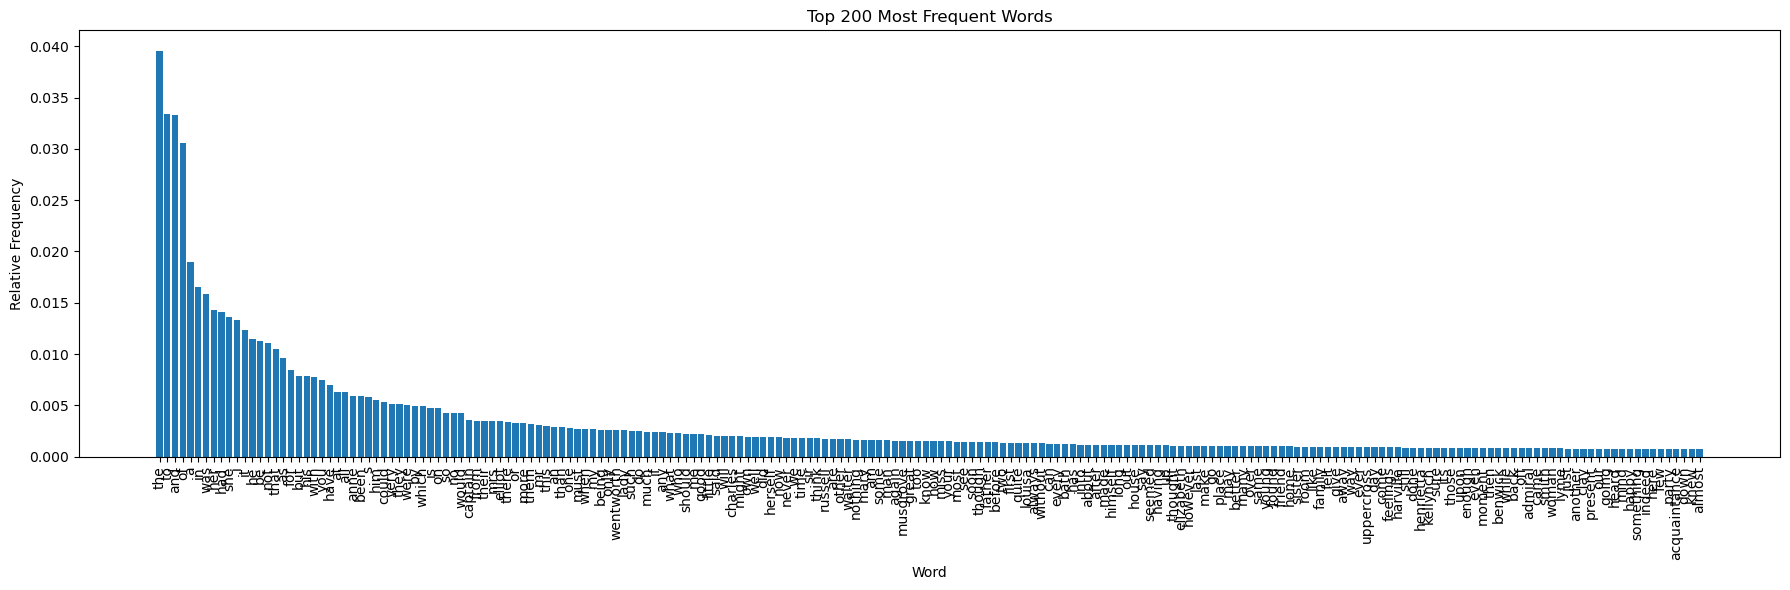

In [17]:
## Graph

plt.figure(figsize=(18,6))

plt.bar(top200_df["Word"], top200_df["Relative Frequency"])

plt.xticks(rotation=90)

plt.xlabel("Word")
plt.ylabel("Relative Frequency")
plt.title("Top 200 Most Frequent Words")

plt.tight_layout()
plt.show()

## Zipf's Law

Zipf's Law states that word frequency decreases approximately inversely with rank.
A log-log plot provides a convenient way to evaluate whether the distribution follows Zipf's Law.

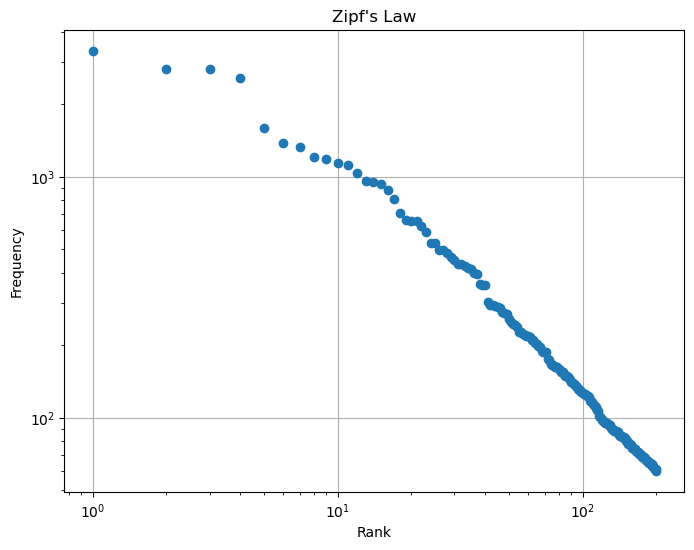

In [18]:
## Zipf Plot

top200_df["Rank"] = range(1,201)

plt.figure(figsize=(8,6))

plt.loglog(top200_df["Rank"],
           top200_df["Frequency"],
           marker='o',
           linestyle='None')

plt.xlabel("Rank")

plt.ylabel("Frequency")

plt.title("Zipf's Law")

plt.grid(True)

plt.show()

## Question 6 Discussion

The word frequencies closely follow Zipf's Law. The highest-ranked words occur much more frequently than lower-ranked words, producing an approximately straight line on the log-log plot. Although there are some deviations among lower-frequency words, the overall distribution matches the expected Zipfian pattern commonly observed in natural language.

## Question 7 Discussion

This corpus differs from "all words in all corpora" because it consists of a single literary work written by one author during a specific historical period. As a result, certain character names, themes, and writing styles appear more frequently than they would in a broader collection of texts. A larger corpus containing newspapers, scientific articles, websites, and books would likely have a more diverse vocabulary and different frequency distribution.

# Conclusion

This project analyzed the word frequency distribution in *Persuasion* by Jane Austen using the NLTK Project Gutenberg corpus. The analysis found 5,740 unique words, while only 58 unique words accounted for half of all word occurrences. The 200 most frequent words exhibited the expected decline in relative frequency, and the log-log plot demonstrated that the corpus closely follows Zipf's Law. Overall, the results illustrate the highly uneven distribution of word frequencies commonly observed in natural language.